# Péndulo simple a partir de un video

### Integrantes

Isaac David Sánchez Sánchez <br> Santiago Andrés Orejuela Cueter <br> Luis Mario Diaz Martínez <br> Maria Valentina Serna Gonzalez

---
## 1. Configuración

Importamos las librerías necesarias y definimos los parámetros del experimento.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.fft import fft, fftfreq
from scipy.signal import savgol_filter
from pathlib import Path

# ─── PARÁMETROS DEL EXPERIMENTO ───────────────────────────────────────
VIDEO_PATH = "IMG_4084.MOV"   # <-- cambia si tu video tiene otro nombre
L_real     = 0.9256            # longitud real de la cuerda en metros
                               # ej: L_real = 0.45  (para 45 cm)
                               # Si es None, no se calcula el valor teórico
MAX_FRAMES = None              # None = procesar todo el video
MIN_BLOB   = 80                # área mínima de blob en px² (filtro de ruido)
N_SAMPLES  = 6                 # cuántos frames de muestra mostrar
# ──────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'figure.facecolor': '#0d0d1a',
    'axes.facecolor':   '#131326',
    'axes.edgecolor':   '#2a2a4a',
    'axes.labelcolor':  '#dde1f0',
    'xtick.color':      '#dde1f0',
    'ytick.color':      '#dde1f0',
    'text.color':       '#dde1f0',
    'grid.color':       '#2a2a4a',
    'grid.linewidth':   0.7,
    'axes.grid':        True,
    'font.family':      'DejaVu Sans',
    'figure.dpi':       110,
})

print('Librerias cargadas correctamente.')
print(f'Video a analizar : {VIDEO_PATH}')
print(f'Longitud real    : {L_real} m' if L_real else 'Longitud real    : no especificada')

Librerias cargadas correctamente.
Video a analizar : IMG_4084.MOV
Longitud real    : 0.9256 m


---
## 2. Carga e inspección del video

Leemos los metadatos del video: resolución, FPS y duración. 

=== Metadatos del video ===
  Archivo    : IMG_4084.MOV
  Resolucion : 3840 x 2160 px
  FPS        : 119.94
  Frames     : 11149
  Duracion   : 92.95 s  (1.5 min)


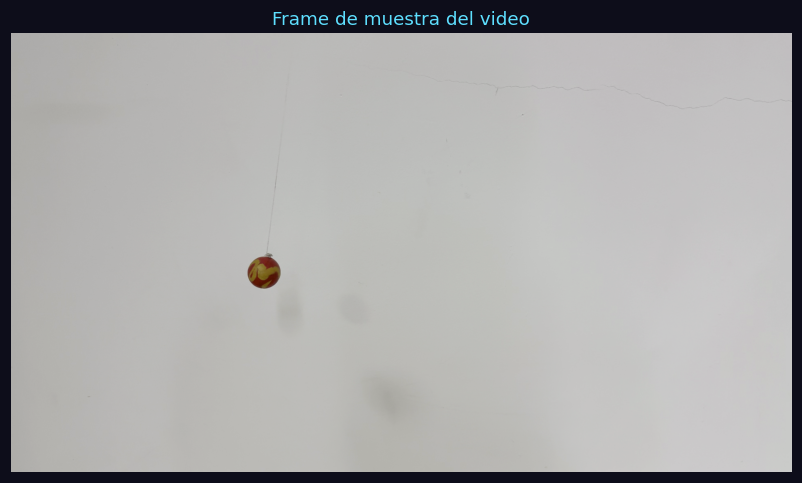

In [2]:
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f'No se puede abrir: {VIDEO_PATH}')

FPS          = cap.get(cv2.CAP_PROP_FPS)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
WIDTH        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
DURATION     = TOTAL_FRAMES / FPS

cap.set(cv2.CAP_PROP_POS_FRAMES, TOTAL_FRAMES // 4)
ret, sample_frame = cap.read()
cap.release()

print('=== Metadatos del video ===')
print(f'  Archivo    : {VIDEO_PATH}')
print(f'  Resolucion : {WIDTH} x {HEIGHT} px')
print(f'  FPS        : {FPS:.2f}')
print(f'  Frames     : {TOTAL_FRAMES}')
print(f'  Duracion   : {DURATION:.2f} s  ({DURATION/60:.1f} min)')

if ret:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.imshow(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))
    ax.set_title('Frame de muestra del video', color='#5edfff', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

---
## 3. Detección automática del péndulo

### Método: Sustracción de fondo (Background Subtraction)

El algoritmo **MOG2** modela el fondo estadísticamente. Al restarlo de cada frame obtenemos solo los píxeles en movimiento.  
Los frames de muestra se guardan **durante este mismo loop** para no tener que releer el video después.

In [3]:
back_sub = cv2.createBackgroundSubtractorMOG2(
    history=60, varThreshold=30, detectShadows=False
)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

cap      = cv2.VideoCapture(VIDEO_PATH)
n_frames = MAX_FRAMES if MAX_FRAMES else TOTAL_FRAMES

sample_indices = set(np.linspace(50, n_frames - 1, N_SAMPLES, dtype=int).tolist())
frames_cache   = {}
masks_cache    = {}

positions_raw = []
timestamps    = []

print(f'Procesando {n_frames} frames...')

for idx in range(n_frames):
    ret, frame = cap.read()
    if not ret:
        break

    fg = back_sub.apply(frame)
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN,  kernel)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel)

    # Guardar frames de muestra sobre la marcha (sin costo extra)
    if idx in sample_indices:
        frames_cache[idx] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        masks_cache[idx]  = fg.copy()

    contours, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    centroid = None
    if contours:
        largest = max(contours, key=cv2.contourArea)
        if cv2.contourArea(largest) >= MIN_BLOB:
            M = cv2.moments(largest)
            if M['m00'] > 0:
                centroid = (int(M['m10'] / M['m00']), int(M['m01'] / M['m00']))

    positions_raw.append(centroid)
    timestamps.append(idx / FPS)

    if (idx + 1) % 500 == 0:
        det = sum(1 for p in positions_raw if p is not None)
        print(f'  {(idx+1)/n_frames*100:.0f}%  |  {idx+1}/{n_frames}  |  Detectados: {det}', end='\r')

cap.release()
timestamps = np.array(timestamps)

detected = sum(1 for p in positions_raw if p is not None)
coverage = detected / len(positions_raw) * 100
print(f'\nTerminado: {detected}/{len(positions_raw)} frames detectados ({coverage:.1f}%)')

Procesando 11149 frames...
  99%  |  11000/11149  |  Detectados: 10416
Terminado: 10559/11149 frames detectados (94.7%)


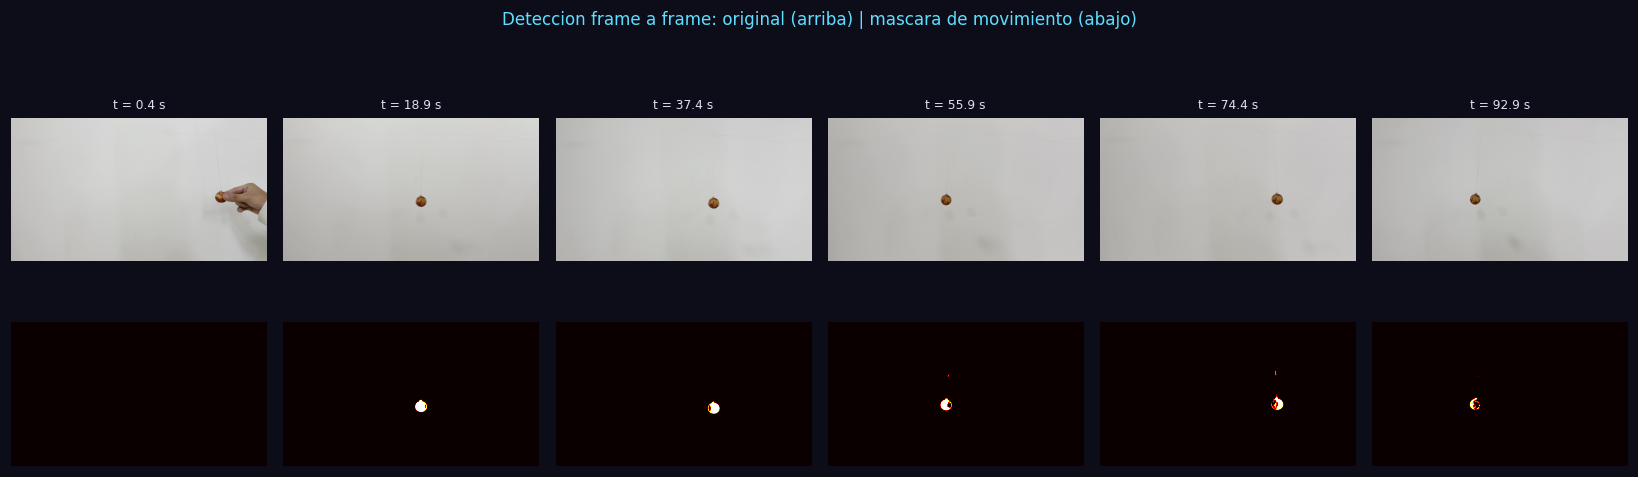

In [4]:
# Visualizar frames de muestra — datos ya en memoria, sin releer el video
sorted_idx = sorted(frames_cache.keys())

fig, axes = plt.subplots(2, len(sorted_idx), figsize=(15, 5))
fig.suptitle('Deteccion frame a frame: original (arriba) | mascara de movimiento (abajo)',
             color='#5edfff', fontsize=11)

for col, idx in enumerate(sorted_idx):
    vis = frames_cache[idx].copy()
    pos = positions_raw[idx]
    if pos:
        cv2.circle(vis, pos, 18, (255, 80, 0), 3)
    axes[0, col].imshow(vis)
    axes[0, col].set_title(f't = {idx/FPS:.1f} s', fontsize=8, color='#dde1f0')
    axes[0, col].axis('off')
    axes[1, col].imshow(masks_cache[idx], cmap='hot')
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

---
## 4. Limpieza y suavizado de datos

1. **Interpolación lineal**: rellena huecos donde no hubo detección.
2. **Filtro Savitzky-Golay**: suaviza ruido sin desfasar la señal.

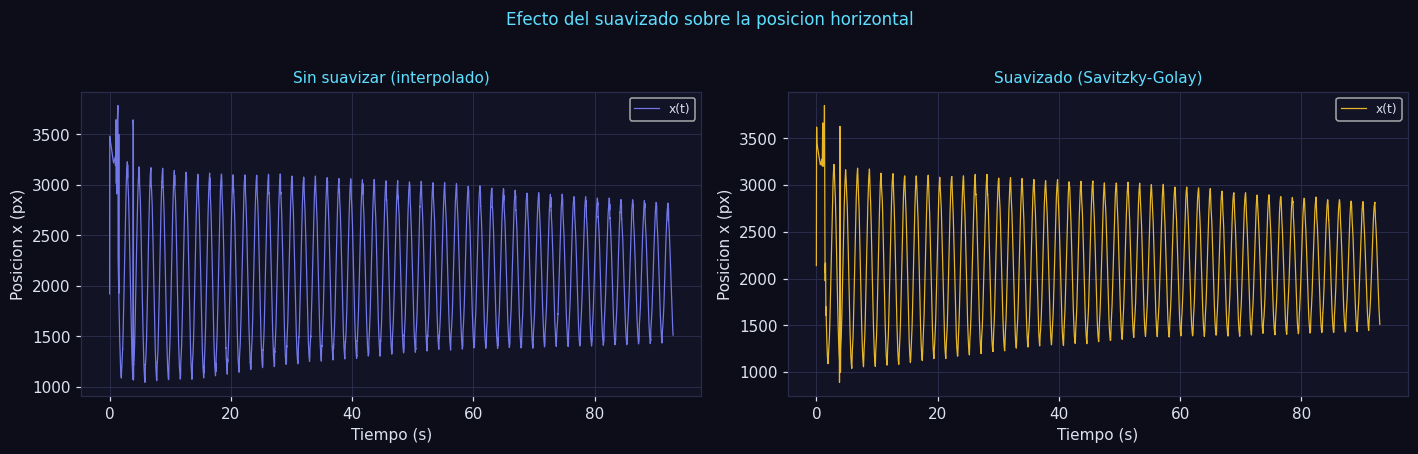

Datos listos: 11149 muestras  |  dt = 8.34 ms por frame


In [5]:
positions_arr = np.array(
    [p if p is not None else [np.nan, np.nan] for p in positions_raw], dtype=float
)

valid   = ~np.isnan(positions_arr[:, 0])
idx_all = np.arange(len(positions_arr))
for col in range(2):
    positions_arr[:, col] = np.interp(idx_all, idx_all[valid], positions_arr[valid, col])

positions_raw_interp = positions_arr.copy()

win = max(5, min(15, len(positions_arr) // 4 * 2 + 1))
positions_smooth = positions_arr.copy()
positions_smooth[:, 0] = savgol_filter(positions_arr[:, 0], window_length=win, polyorder=3)
positions_smooth[:, 1] = savgol_filter(positions_arr[:, 1], window_length=win, polyorder=3)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, pos, label, col in zip(
    axes,
    [positions_raw_interp, positions_smooth],
    ['Sin suavizar (interpolado)', 'Suavizado (Savitzky-Golay)'],
    ['#7c83fd', '#ffca28']
):
    ax.plot(timestamps, pos[:, 0], color=col, lw=0.8, alpha=0.9, label='x(t)')
    ax.set_title(label, color='#5edfff', fontsize=10)
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Posicion x (px)')
    ax.legend(fontsize=8)

plt.suptitle('Efecto del suavizado sobre la posicion horizontal',
             color='#5edfff', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

positions = positions_smooth
print(f'Datos listos: {len(positions)} muestras  |  dt = {1/FPS*1000:.2f} ms por frame')

=== Recorte de transitorio inicial ===
Segundos recortados       : 4.00 s
Muestras eliminadas       : 479
Muestras restantes        : 10670
Tiempo analizado restante : 88.95 s


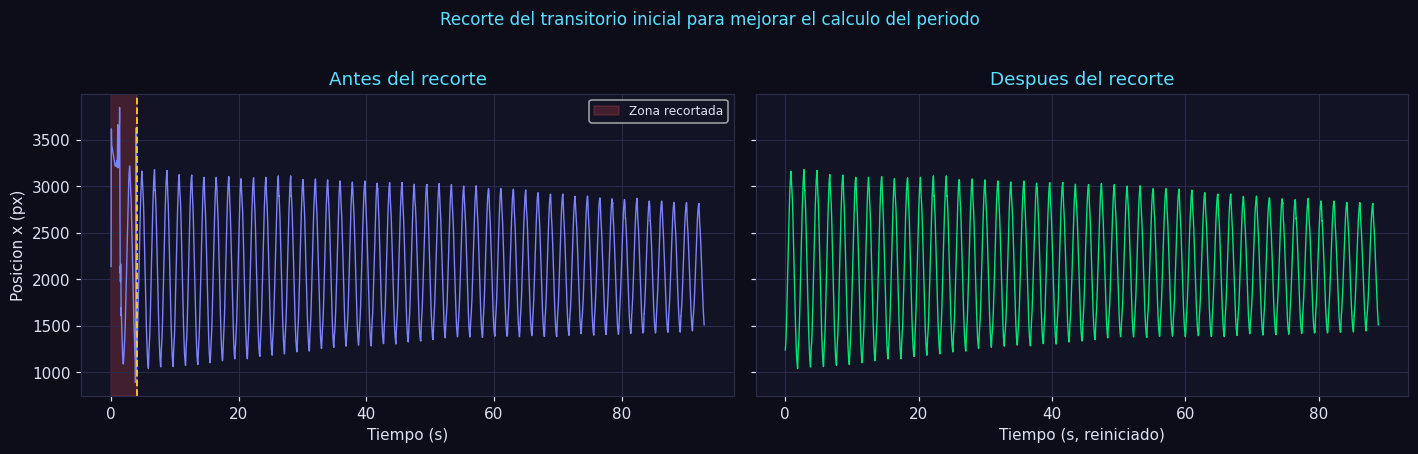

In [13]:
# Recorte de los primeros segundos (transitorio inicial)
TRIM_SECONDS = 4.0  # Ajusta este valor segun el video

trim_idx = int(TRIM_SECONDS * FPS)
if trim_idx >= len(timestamps) - 10:
    raise ValueError('TRIM_SECONDS es demasiado grande para este video.')

# Guardamos copia para demostrar el recorte en la grafica
timestamps_full = timestamps.copy()
positions_full = positions.copy()

# Recorte y reinicio del tiempo para facilitar la interpretacion
timestamps = timestamps[trim_idx:] - timestamps[trim_idx]
positions  = positions[trim_idx:]

print('=== Recorte de transitorio inicial ===')
print(f'Segundos recortados       : {TRIM_SECONDS:.2f} s')
print(f'Muestras eliminadas       : {trim_idx}')
print(f'Muestras restantes        : {len(timestamps)}')
print(f'Tiempo analizado restante : {timestamps[-1]:.2f} s')

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

axes[0].plot(timestamps_full, positions_full[:, 0], color='#7c83fd', lw=0.9)
axes[0].axvspan(0, TRIM_SECONDS, color='#ff5252', alpha=0.20, label='Zona recortada')
axes[0].axvline(TRIM_SECONDS, color='#ffca28', ls='--', lw=1.2)
axes[0].set_title('Antes del recorte', color='#5edfff')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Posicion x (px)')
axes[0].legend(fontsize=8)

axes[1].plot(timestamps, positions[:, 0], color='#00e676', lw=0.9)
axes[1].set_title('Despues del recorte', color='#5edfff')
axes[1].set_xlabel('Tiempo (s, reiniciado)')

plt.suptitle('Recorte del transitorio inicial para mejorar el calculo del periodo',
             color='#5edfff', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Estimación del pivote y cálculo del ángulo

El péndulo traza un arco circular. Ajustamos un **círculo por mínimos cuadrados** para estimar el pivote y la longitud.  
El ángulo desde la vertical:

$$\theta(t) = \arctan\!\left(\frac{x(t) - x_0}{y(t) - y_0}\right)$$

=== Geometria del pendulo ===
  Pivote estimado : (2227.9, -5211.2) px
  Longitud (px)   : 3249.6 px
  Amplitud maxima : 10.57 deg


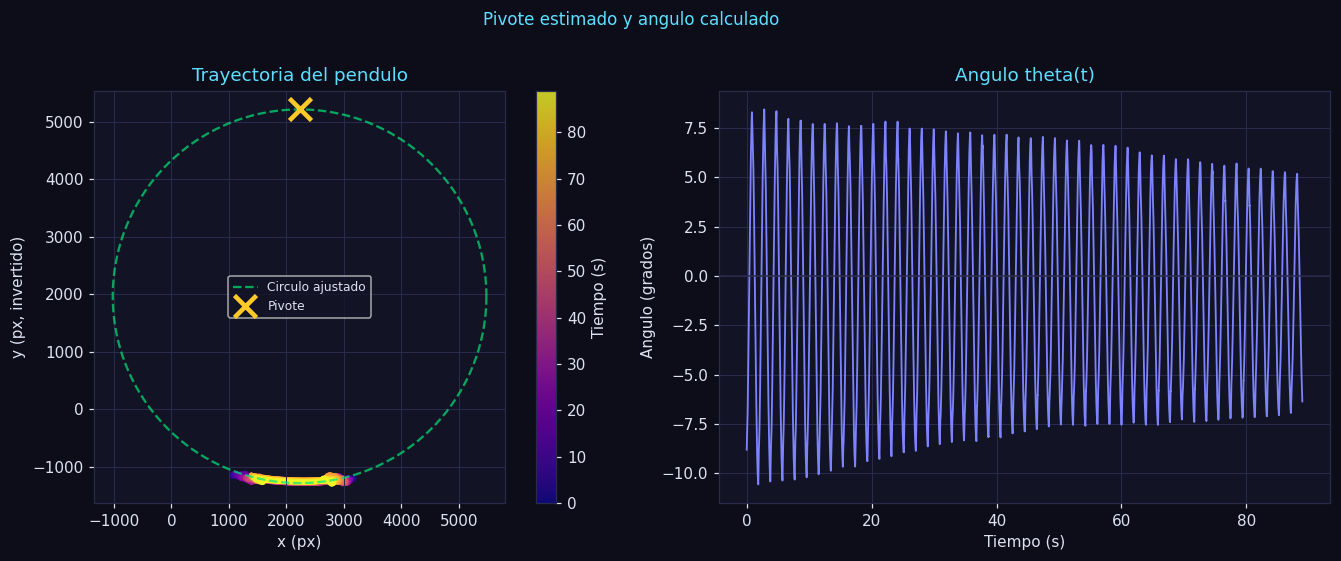

In [14]:
def fit_circle(pts):
    x, y = pts[:, 0], pts[:, 1]
    A = np.column_stack([2*x, 2*y, np.ones(len(x))])
    b = x**2 + y**2
    res, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy = res[0], res[1]
    r = np.sqrt(max(0, res[2] + cx**2 + cy**2))
    return cx, cy, r

cx, cy, radius = fit_circle(positions)
mean_y = np.mean(positions[:, 1])
pivot  = np.array([cx, cy - radius if mean_y > cy else cy + radius])

dx     = positions[:, 0] - pivot[0]
dy     = positions[:, 1] - pivot[1]
angles = np.arctan2(dx, dy)

print('=== Geometria del pendulo ===')
print(f'  Pivote estimado : ({pivot[0]:.1f}, {pivot[1]:.1f}) px')
print(f'  Longitud (px)   : {radius:.1f} px')
print(f'  Amplitud maxima : {np.degrees(np.max(np.abs(angles))):.2f} deg')

theta_plot = np.linspace(0, 2*np.pi, 300)
fig, axes  = plt.subplots(1, 2, figsize=(13, 5))

sc = axes[0].scatter(positions[:, 0], -positions[:, 1], c=timestamps, cmap='plasma', s=4, alpha=0.8)
axes[0].plot(cx + radius*np.cos(theta_plot), -(cy + radius*np.sin(theta_plot)),
             '--', color='#00e676', lw=1.5, label='Circulo ajustado', alpha=0.7)
axes[0].plot(pivot[0], -pivot[1], 'x', color='#ffca28', ms=14, mew=3, label='Pivote')
plt.colorbar(sc, ax=axes[0], label='Tiempo (s)')
axes[0].set_title('Trayectoria del pendulo', color='#5edfff')
axes[0].set_xlabel('x (px)')
axes[0].set_ylabel('y (px, invertido)')
axes[0].legend(fontsize=8)
axes[0].set_aspect('equal')

axes[1].plot(timestamps, np.degrees(angles), color='#7c83fd', lw=1.2)
axes[1].axhline(0, color='#2a2a4a', lw=1)
axes[1].set_title('Angulo theta(t)', color='#5edfff')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Angulo (grados)')

plt.suptitle('Pivote estimado y angulo calculado', color='#5edfff', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Estimación del período — Cruces por cero

$$T = 2 \cdot \overline{\Delta t_{\text{cruces}}}$$

Cruces detectados  : 92
Ciclos completos   : 91
Periodo estimado   : T = 1.9379 +/- 0.0457 s


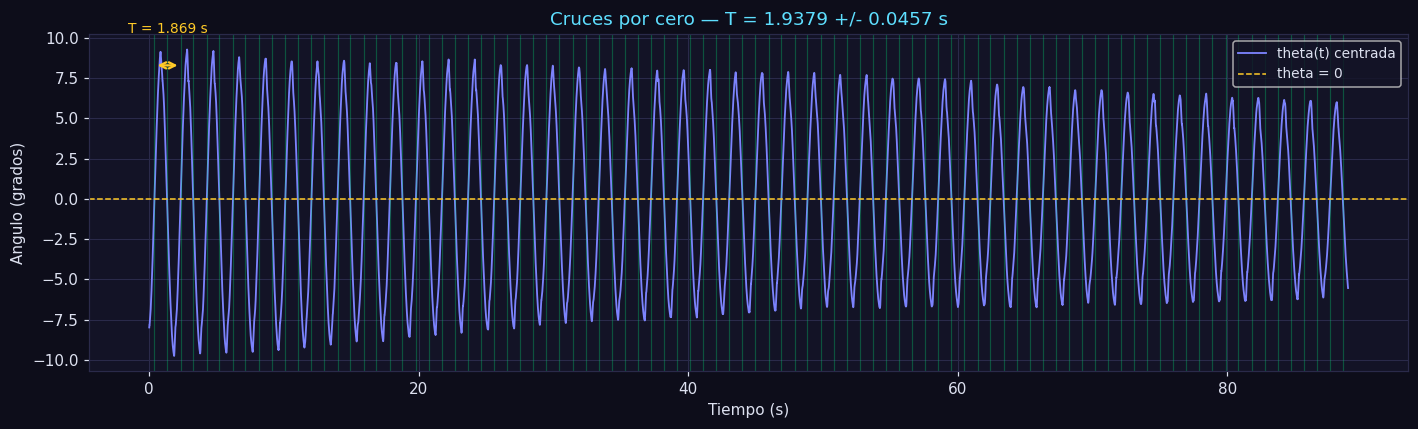

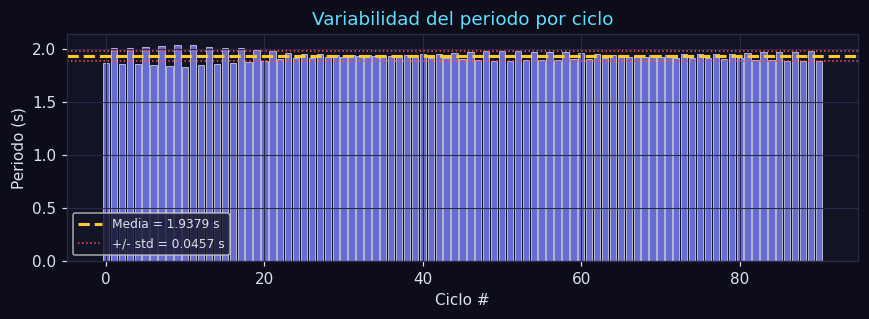

In [15]:
sig = angles - np.mean(angles)

crossings = []
for i in range(1, len(sig)):
    if sig[i-1] * sig[i] < 0:
        t_c = timestamps[i-1] + (timestamps[i] - timestamps[i-1]) * (-sig[i-1] / (sig[i] - sig[i-1]))
        crossings.append(t_c)

half_periods = np.diff(crossings)
full_periods = 2 * half_periods
T_zc         = np.mean(full_periods)
T_zc_std     = np.std(full_periods)

print(f'Cruces detectados  : {len(crossings)}')
print(f'Ciclos completos   : {len(full_periods)}')
print(f'Periodo estimado   : T = {T_zc:.4f} +/- {T_zc_std:.4f} s')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(timestamps, np.degrees(sig), color='#7c83fd', lw=1.2, label='theta(t) centrada')
for tc in crossings:
    ax.axvline(tc, color='#00e676', alpha=0.3, lw=0.8)
ax.axhline(0, color='#ffca28', lw=1, ls='--', label='theta = 0')

if len(crossings) >= 3:
    mid_t = (crossings[0] + crossings[2]) / 2
    y_ann = np.degrees(np.max(np.abs(sig))) * 0.85
    ax.annotate('', xy=(crossings[2], y_ann), xytext=(crossings[0], y_ann),
                arrowprops=dict(arrowstyle='<->', color='#ffca28', lw=1.5))
    ax.text(mid_t, y_ann + 2, f'T = {full_periods[0]:.3f} s', ha='center', color='#ffca28', fontsize=9)

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Angulo (grados)')
ax.set_title(f'Cruces por cero — T = {T_zc:.4f} +/- {T_zc_std:.4f} s', color='#5edfff')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 3))
ax2.bar(range(len(full_periods)), full_periods, color='#7c83fd', alpha=0.8, edgecolor='white', lw=0.5)
ax2.axhline(T_zc, color='#ffca28', lw=2, ls='--', label=f'Media = {T_zc:.4f} s')
ax2.axhline(T_zc + T_zc_std, color='#ff5252', lw=1, ls=':')
ax2.axhline(T_zc - T_zc_std, color='#ff5252', lw=1, ls=':', label=f'+/- std = {T_zc_std:.4f} s')
ax2.set_xlabel('Ciclo #')
ax2.set_ylabel('Periodo (s)')
ax2.set_title('Variabilidad del periodo por ciclo', color='#5edfff')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 7. Estimación del período — FFT

$$T = \frac{1}{f_0}$$

La FFT descompone $\theta(t)$ en frecuencias. El pico dominante corresponde a la frecuencia de oscilación.

Frecuencia dominante  : f = 0.5171 Hz
Periodo estimado      : T = 1.9339 s
Resolucion frecuencial: df = 0.01124 Hz


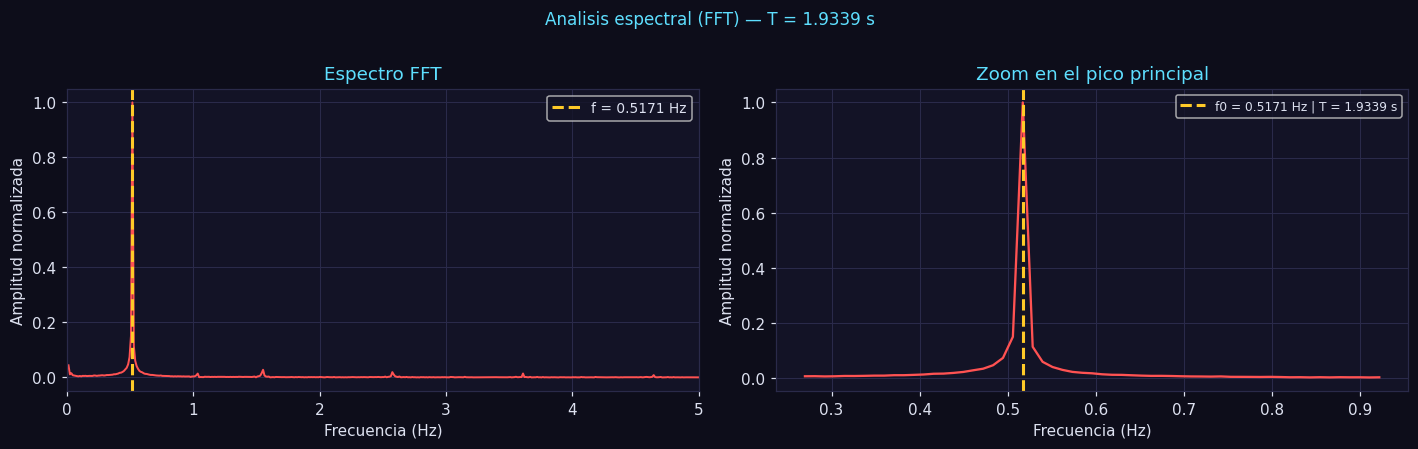

In [16]:
sig_fft  = angles - np.mean(angles)
N        = len(sig_fft)
dt       = np.mean(np.diff(timestamps))
freqs    = fftfreq(N, dt)
spectrum = np.abs(fft(sig_fft))

pos_mask  = freqs > 0
freqs_pos = freqs[pos_mask]
spec_pos  = spectrum[pos_mask]

peak_idx = np.argmax(spec_pos)
f_dom    = freqs_pos[peak_idx]
T_fft    = 1.0 / f_dom

print(f'Frecuencia dominante  : f = {f_dom:.4f} Hz')
print(f'Periodo estimado      : T = {T_fft:.4f} s')
print(f'Resolucion frecuencial: df = {freqs_pos[1]-freqs_pos[0]:.5f} Hz')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(freqs_pos, spec_pos / spec_pos.max(), color='#ff5252', lw=1.3)
axes[0].axvline(f_dom, color='#ffca28', lw=2, ls='--', label=f'f = {f_dom:.4f} Hz')
axes[0].set_xlim(0, min(5.0, freqs_pos[-1]))
axes[0].set_xlabel('Frecuencia (Hz)')
axes[0].set_ylabel('Amplitud normalizada')
axes[0].set_title('Espectro FFT', color='#5edfff')
axes[0].legend(fontsize=9)

zoom_mask = (freqs_pos > f_dom * 0.5) & (freqs_pos < f_dom * 1.8)
axes[1].plot(freqs_pos[zoom_mask], spec_pos[zoom_mask] / spec_pos.max(), color='#ff5252', lw=1.5)
axes[1].axvline(f_dom, color='#ffca28', lw=2, ls='--', label=f'f0 = {f_dom:.4f} Hz | T = {T_fft:.4f} s')
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('Amplitud normalizada')
axes[1].set_title('Zoom en el pico principal', color='#5edfff')
axes[1].legend(fontsize=8)

plt.suptitle(f'Analisis espectral (FFT) — T = {T_fft:.4f} s', color='#5edfff', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Estimación del período — Ajuste sinusoidal

$$\theta(t) = A \cos(\omega t + \phi) + C \quad \Rightarrow \quad T = \frac{2\pi}{\omega}$$

=== Ajuste sinusoidal ===
  Amplitud  A   : -7.075 +/- 0.0104 deg
  Frecuencia w  : 3.24136 +/- 0.000057 rad/s
  Periodo T     : 1.9384 +/- 0.00003 s
  Frecuencia f  : 0.51588 Hz
  RMSE residuos : 0.7583 deg


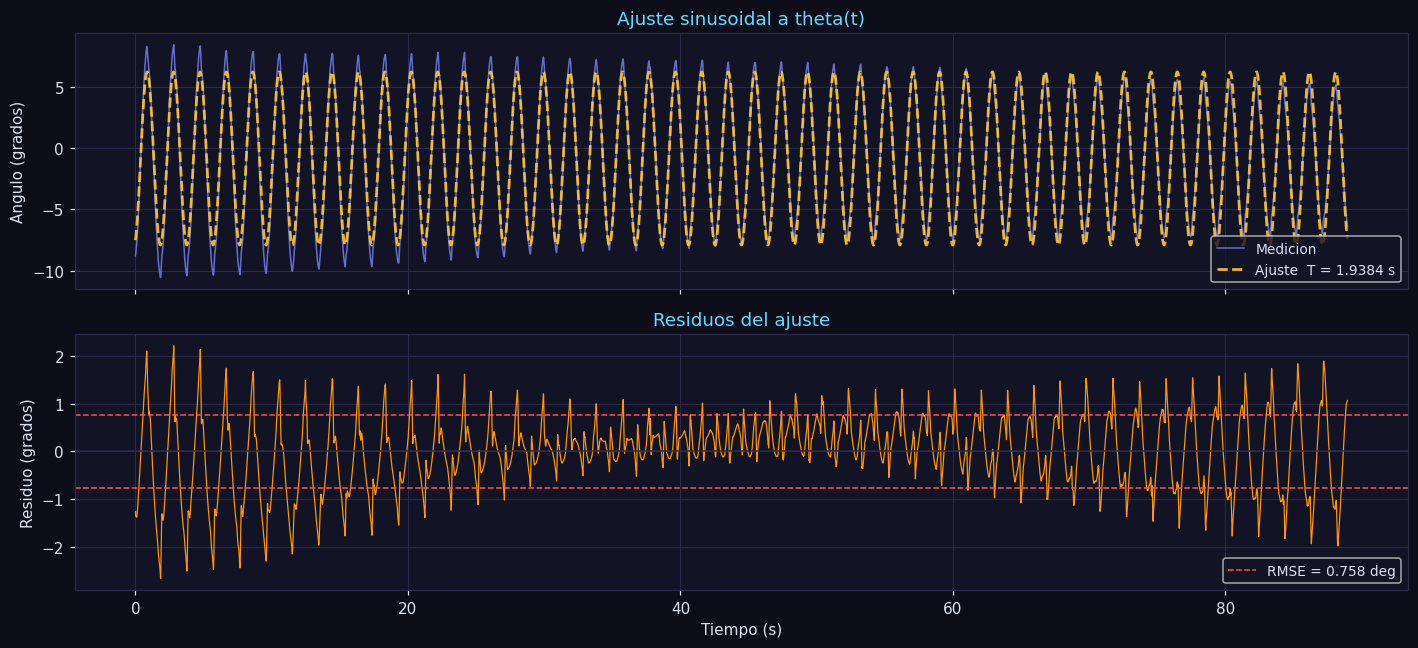

In [17]:
def sinusoid(t, A, omega, phi, C):
    return A * np.cos(omega * t + phi) + C

popt, pcov = curve_fit(
    sinusoid, timestamps, angles,
    p0=[(np.max(angles)-np.min(angles))/2, 2*np.pi/T_fft, 0.0, np.mean(angles)],
    maxfev=20000
)

A_fit, omega_fit, phi_fit, C_fit = popt
perr      = np.sqrt(np.diag(pcov))
T_fit     = 2 * np.pi / abs(omega_fit)
T_fit_err = abs(2 * np.pi / omega_fit**2 * perr[1])
f_fit     = 1.0 / T_fit

fitted_angles = sinusoid(timestamps, *popt)
residuals     = angles - fitted_angles
rmse          = np.sqrt(np.mean(residuals**2))

print('=== Ajuste sinusoidal ===')
print(f'  Amplitud  A   : {np.degrees(A_fit):.3f} +/- {np.degrees(perr[0]):.4f} deg')
print(f'  Frecuencia w  : {omega_fit:.5f} +/- {perr[1]:.6f} rad/s')
print(f'  Periodo T     : {T_fit:.4f} +/- {T_fit_err:.5f} s')
print(f'  Frecuencia f  : {f_fit:.5f} Hz')
print(f'  RMSE residuos : {np.degrees(rmse):.4f} deg')

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(timestamps, np.degrees(angles), color='#7c83fd', lw=1.0, alpha=0.8, label='Medicion')
axes[0].plot(timestamps, np.degrees(fitted_angles), '--', color='#ffca28',
             lw=1.8, alpha=0.9, label=f'Ajuste  T = {T_fit:.4f} s')
axes[0].set_ylabel('Angulo (grados)')
axes[0].set_title('Ajuste sinusoidal a theta(t)', color='#5edfff')
axes[0].legend(fontsize=9)

axes[1].plot(timestamps, np.degrees(residuals), color='#ff9800', lw=0.8)
axes[1].axhline(0, color='#2a2a4a', lw=1)
axes[1].axhline( np.degrees(rmse), color='#ff5252', lw=1, ls='--', label=f'RMSE = {np.degrees(rmse):.3f} deg')
axes[1].axhline(-np.degrees(rmse), color='#ff5252', lw=1, ls='--')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Residuo (grados)')
axes[1].set_title('Residuos del ajuste', color='#5edfff')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 9. Comparación con valor teórico

$$T_{\text{teórico}} = 2\pi\sqrt{\frac{L}{g}}, \qquad T_{\text{corr.}} = T_{\text{teórico}}\left(1 + \frac{\theta_0^2}{16}\right)$$

  Metodo                          T (s)       Incert.
  Cruces por cero                1.9379    +/- 0.0457
  FFT                            1.9339             —
  Ajuste sinusoidal              1.9384    +/- 0.0000
  Teorico (lineal)               1.9303             —
  Teorico (corregido)            1.9344             —
  Error vs. teorico lineal   : 0.42 %
  Error vs. teorico corregido: 0.21 %


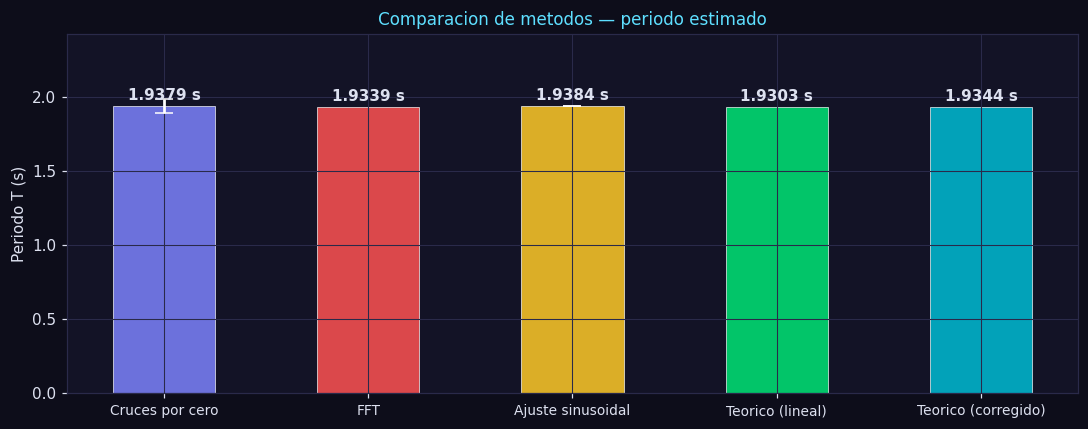

In [18]:
g = 9.80665

results = {
    'Cruces por cero'   : (T_zc,  T_zc_std),
    'FFT'               : (T_fft, None),
    'Ajuste sinusoidal' : (T_fit, T_fit_err),
}

T_theory = T_theory_corr = None
if L_real is not None:
    T_theory      = 2 * np.pi * np.sqrt(L_real / g)
    theta0        = np.max(np.abs(angles))
    T_theory_corr = T_theory * (1 + (1/16) * theta0**2)
    results['Teorico (lineal)']     = (T_theory,      None)
    results['Teorico (corregido)']  = (T_theory_corr, None)

print('=' * 55)
print(f'  {"Metodo":<25}  {"T (s)":>10}  {"Incert.":>12}')
print('=' * 55)
for metodo, (T, dT) in results.items():
    dT_str = f'+/- {dT:.4f}' if dT else '    —'
    print(f'  {metodo:<25}  {T:>10.4f}  {dT_str:>12}')

if L_real is not None:
    print('=' * 55)
    print(f'  Error vs. teorico lineal   : {abs(T_fit - T_theory)/T_theory*100:.2f} %')
    print(f'  Error vs. teorico corregido: {abs(T_fit - T_theory_corr)/T_theory_corr*100:.2f} %')

fig, ax = plt.subplots(figsize=(10, 4))
colors  = ['#7c83fd', '#ff5252', '#ffca28', '#00e676', '#00bcd4']
labels  = list(results.keys())
values  = [v[0] for v in results.values()]
errors  = [v[1] for v in results.values()]
xs      = np.arange(len(labels))

ax.bar(xs, values, color=colors[:len(labels)], width=0.5, alpha=0.85, edgecolor='white', linewidth=0.5)
for i, (v, e) in enumerate(zip(values, errors)):
    if e:
        ax.errorbar(i, v, yerr=e, fmt='none', color='white', capsize=6, lw=1.8)
    ax.text(i, v + max(values)*0.01, f'{v:.4f} s',
            ha='center', va='bottom', color='#dde1f0', fontsize=10, fontweight='bold')

ax.set_xticks(xs)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Periodo T (s)')
ax.set_ylim(0, max(values) * 1.25)
ax.set_title('Comparacion de metodos — periodo estimado', color='#5edfff', fontsize=11)
plt.tight_layout()
plt.show()

---
## 10. Comparación visual: señal medida vs señal teórica

Aquí construimos la **oscilación teórica** usando $\omega_{\text{teórico}} = 2\pi/T_{\text{teórico}}$ con la misma amplitud y fase inicial del ajuste,  
y la superponemos sobre la señal medida. Esto permite ver directamente:

- Si las **frecuencias coinciden** (las curvas se mantienen en fase)
- Si hay **deriva de fase** acumulada (las curvas se van separando con el tiempo)
- La diferencia en el **espectro de frecuencias**

> Nota: Si `L_real = None`, el teórico se estima **invirtiendo la formula**: $L = g\,(T_{\text{ajuste}}/2\pi)^2$


  f medida   : 0.51588 Hz  (T = 1.9384 s)
  f teorica  : 0.51695 Hz  (T = 1.9344 s)
  Delta f    : 1.0689 mHz
  Delta omega: 0.00672 rad/s


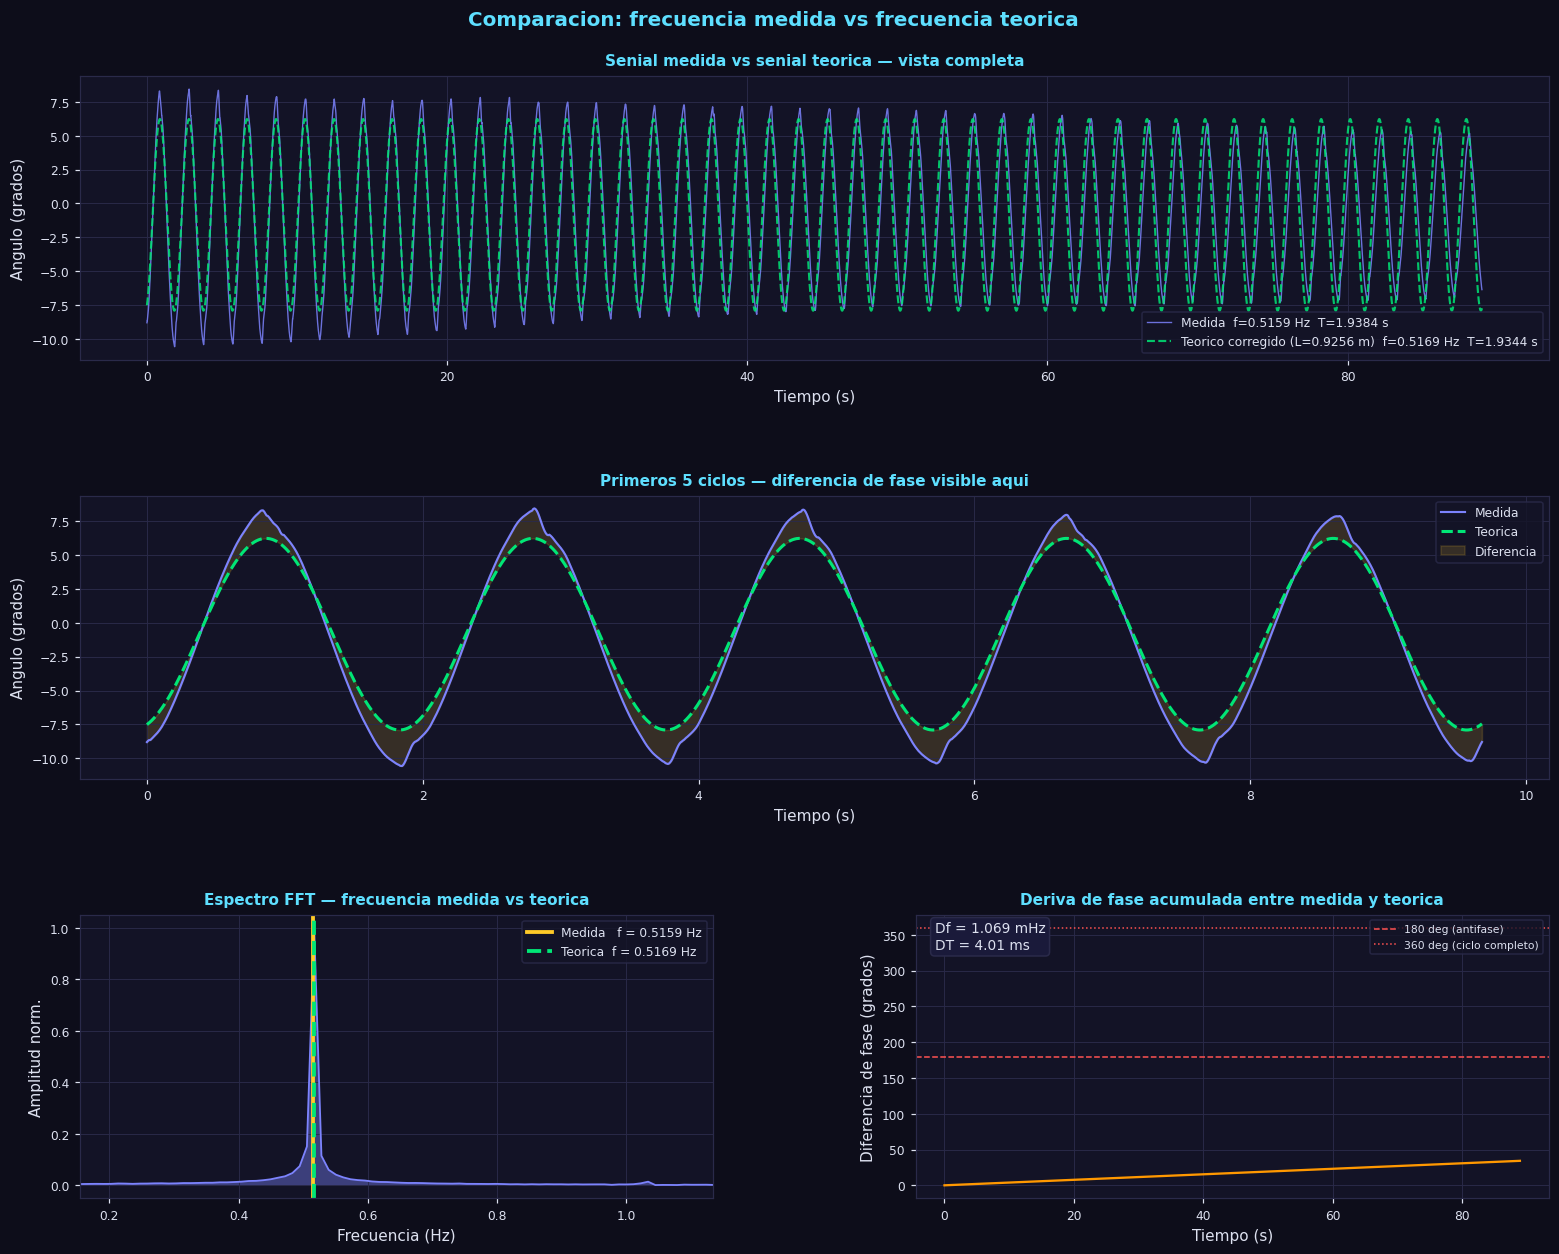


  Diferencia absoluta en T : 4.01 ms
  Diferencia relativa      : 0.207 %
  Las seniales llegarian a antifase en: 467.8 s  (241 ciclos)


In [19]:
# ── Frecuencias ──────────────────────────────────────────────────────
f_medida = f_fit          # del ajuste sinusoidal (más preciso)
T_medida = T_fit

if L_real is not None:
    T_ref  = T_theory_corr    # teórico con corrección de ángulo grande
    f_ref  = 1.0 / T_ref
    label_ref = f'Teorico corregido (L={L_real} m)'
else:
    # Sin L_real: estimamos L a partir del periodo medido
    L_est  = g * (T_fit / (2 * np.pi))**2
    T_ref  = T_fit            # coincide con medido (para mostrar igual)
    f_ref  = f_fit
    label_ref = f'Teorico estimado (L est. = {L_est*100:.1f} cm)'
    print(f'L_real no definido. Longitud estimada: {L_est:.4f} m ({L_est*100:.1f} cm)')
    print('Para ver diferencias reales, asigna L_real en la celda 1.')

# Señal teórica con misma amplitud y fase que el ajuste
theta_teorica = A_fit * np.cos(2 * np.pi * f_ref * timestamps + phi_fit) + C_fit

# Delta de fase acumulado
delta_omega   = abs(omega_fit - 2 * np.pi * f_ref)      # rad/s
phase_drift   = np.degrees(delta_omega * timestamps)      # grados acumulados

print(f'\n  f medida   : {f_medida:.5f} Hz  (T = {T_medida:.4f} s)')
print(f'  f teorica  : {f_ref:.5f} Hz  (T = {T_ref:.4f} s)')
print(f'  Delta f    : {abs(f_medida - f_ref)*1000:.4f} mHz')
print(f'  Delta omega: {delta_omega:.5f} rad/s')

# ── FIGURA ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 12))
fig.patch.set_facecolor('#0d0d1a')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.32,
                        top=0.92, bottom=0.07, left=0.08, right=0.97)

ax1 = fig.add_subplot(gs[0, :])   # señales superpuestas — vista completa
ax2 = fig.add_subplot(gs[1, :])   # zoom primeros 5 ciclos
ax3 = fig.add_subplot(gs[2, 0])   # espectro FFT con ambas frecuencias
ax4 = fig.add_subplot(gs[2, 1])   # deriva de fase acumulada

def sax(ax, title):
    ax.set_facecolor('#131326')
    ax.set_title(title, color='#5edfff', fontsize=10, fontweight='bold', pad=7)
    ax.tick_params(colors='#dde1f0', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#2a2a4a')
    ax.grid(True, color='#2a2a4a', lw=0.6)
    ax.xaxis.label.set_color('#dde1f0')
    ax.yaxis.label.set_color('#dde1f0')

# ── Panel 1: señales completas ────────────────────────────────────────
sax(ax1, 'Senial medida vs senial teorica — vista completa')
ax1.plot(timestamps, np.degrees(angles),       color='#7c83fd', lw=0.9, alpha=0.85,
         label=f'Medida  f={f_medida:.4f} Hz  T={T_medida:.4f} s')
ax1.plot(timestamps, np.degrees(theta_teorica), '--', color='#00e676', lw=1.4, alpha=0.85,
         label=f'{label_ref}  f={f_ref:.4f} Hz  T={T_ref:.4f} s')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Angulo (grados)')
ax1.legend(fontsize=8, facecolor='#131326', edgecolor='#2a2a4a', labelcolor='#dde1f0')

# ── Panel 2: zoom (primeros 5 ciclos) ────────────────────────────────
n_show = int(5 * T_medida * FPS)
sax(ax2, f'Primeros 5 ciclos — diferencia de fase visible aqui')
ax2.plot(timestamps[:n_show], np.degrees(angles[:n_show]),
         color='#7c83fd', lw=1.4, label='Medida')
ax2.plot(timestamps[:n_show], np.degrees(theta_teorica[:n_show]),
         '--', color='#00e676', lw=2.0, label='Teorica')
ax2.fill_between(timestamps[:n_show],
                 np.degrees(angles[:n_show]),
                 np.degrees(theta_teorica[:n_show]),
                 alpha=0.15, color='#ffca28', label='Diferencia')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Angulo (grados)')
ax2.legend(fontsize=8, facecolor='#131326', edgecolor='#2a2a4a', labelcolor='#dde1f0')

# ── Panel 3: espectro FFT con ambas frecuencias ───────────────────────
sax(ax3, 'Espectro FFT — frecuencia medida vs teorica')
ax3.fill_between(freqs_pos, spec_pos / spec_pos.max(),
                 color='#7c83fd', alpha=0.4, linewidth=0)
ax3.plot(freqs_pos, spec_pos / spec_pos.max(), color='#7c83fd', lw=1.2)
ax3.axvline(f_medida, color='#ffca28', lw=2.5, ls='-',
            label=f'Medida   f = {f_medida:.4f} Hz')
ax3.axvline(f_ref,    color='#00e676', lw=2.5, ls='--',
            label=f'Teorica  f = {f_ref:.4f} Hz')
ax3.set_xlim(max(0, f_medida * 0.3), f_medida * 2.2)
ax3.set_xlabel('Frecuencia (Hz)')
ax3.set_ylabel('Amplitud norm.')
ax3.legend(fontsize=8, facecolor='#131326', edgecolor='#2a2a4a', labelcolor='#dde1f0')

# ── Panel 4: deriva de fase acumulada ────────────────────────────────
sax(ax4, 'Deriva de fase acumulada entre medida y teorica')
ax4.plot(timestamps, phase_drift, color='#ff9800', lw=1.5)
ax4.axhline(180, color='#ff5252', lw=1, ls='--', label='180 deg (antifase)')
ax4.axhline(360, color='#ff5252', lw=1, ls=':', label='360 deg (ciclo completo)')
ax4.set_xlabel('Tiempo (s)')
ax4.set_ylabel('Diferencia de fase (grados)')
ax4.legend(fontsize=7, facecolor='#131326', edgecolor='#2a2a4a', labelcolor='#dde1f0')

# Anotar valores clave
ax4.text(0.03, 0.88,
         f'Df = {abs(f_medida-f_ref)*1000:.3f} mHz\nDT = {abs(T_medida-T_ref)*1000:.2f} ms',
         transform=ax4.transAxes, color='#dde1f0', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#1a1a3a', edgecolor='#2a2a4a'))

fig.suptitle('Comparacion: frecuencia medida vs frecuencia teorica',
             color='#5edfff', fontsize=13, fontweight='bold', y=0.97)
plt.show()

print(f'\n  Diferencia absoluta en T : {abs(T_medida - T_ref)*1000:.2f} ms')
print(f'  Diferencia relativa      : {abs(T_medida - T_ref)/T_ref*100:.3f} %')
if delta_omega > 0:
    t_antifase = np.pi / delta_omega
    print(f'  Las seniales llegarian a antifase en: {t_antifase:.1f} s  ({t_antifase/T_medida:.0f} ciclos)')

---
## 11. Discusión de errores

Análisis cuantitativo de las principales fuentes de incertidumbre.

=== Analisis de errores y limitaciones ===

1. Resolucion temporal
   FPS = 119.9  ->  resolucion = 8.3 ms/frame
   Error maximo en T: ~0.43%

2. No linealidad (angulo grande)
   Amplitud maxima: 10.6 deg
   ADVERTENCIA: aprox. lineal introduce ~0.21% de error en T

3. Cobertura de deteccion: 94.7%
   Cobertura alta -> interpolacion de bajo impacto.

4. Movimiento 3D: el video captura solo 2D.
5. Estabilidad de camara: vibraciones = ruido en posicion detectada.
6. Amortiguamiento: el modelo A*cos(wt+phi) no incluye disipacion.

   Amplitud inicio : 10.57 deg
   Amplitud final  : 7.40 deg
   Decaimiento     : 30.0%


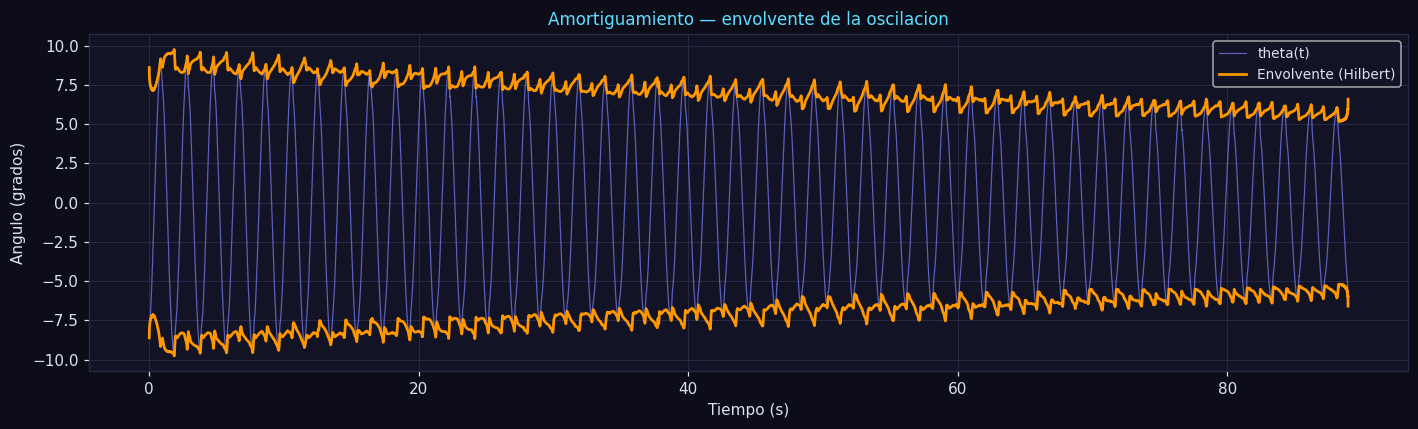


=== RESUMEN FINAL ===
  Periodo (ajuste sinusoidal): T = 1.9384 +/- 0.00003 s
  Frecuencia                 : f = 0.51588 Hz
  Longitud real              : L = 0.9256 m
  Valor teorico (lineal)     : T = 1.9303 s
  Valor teorico (corregido)  : T = 1.9344 s
  Error relativo             : 0.21%


In [20]:
theta_max  = np.max(np.abs(angles))
amp_deg    = np.degrees(theta_max)
corr_ang   = (1/16) * theta_max**2
cov        = sum(1 for p in positions_raw if p is not None) / len(positions_raw)

print('=== Analisis de errores y limitaciones ===')
print()
print(f'1. Resolucion temporal')
print(f'   FPS = {FPS:.1f}  ->  resolucion = {1/FPS*1000:.1f} ms/frame')
print(f'   Error maximo en T: ~{1/FPS/T_fit*100:.2f}%')
print()
print(f'2. No linealidad (angulo grande)')
print(f'   Amplitud maxima: {amp_deg:.1f} deg')
if amp_deg > 10:
    print(f'   ADVERTENCIA: aprox. lineal introduce ~{corr_ang*100:.2f}% de error en T')
else:
    print(f'   Angulo pequeno -> approx. lineal valida (error < 0.5%)')
print()
print(f'3. Cobertura de deteccion: {cov*100:.1f}%')
if cov < 0.85:
    print('   ADVERTENCIA: cobertura baja, posible sesgo por interpolacion.')
else:
    print('   Cobertura alta -> interpolacion de bajo impacto.')
print()
print(f'4. Movimiento 3D: el video captura solo 2D.')
print(f'5. Estabilidad de camara: vibraciones = ruido en posicion detectada.')
print(f'6. Amortiguamiento: el modelo A*cos(wt+phi) no incluye disipacion.')

fps_int    = int(T_fit * FPS)
n_ciclos   = max(1, int(len(timestamps) / fps_int) // 5)
amp_inicio = np.max(np.abs(angles[:n_ciclos * fps_int]))
amp_final  = np.max(np.abs(angles[-n_ciclos * fps_int:]))
decaim     = (1 - amp_final / amp_inicio) * 100 if amp_inicio > 0 else 0
print(f'\n   Amplitud inicio : {np.degrees(amp_inicio):.2f} deg')
print(f'   Amplitud final  : {np.degrees(amp_final):.2f} deg')
print(f'   Decaimiento     : {decaim:.1f}%')

# Envolvente de amortiguamiento
from scipy.signal import hilbert
analytic = hilbert(angles - np.mean(angles))
envelope = np.abs(analytic)

fig, ax = plt.subplots(figsize=(13, 4))
ax.set_facecolor('#131326')
ax.plot(timestamps, np.degrees(angles - np.mean(angles)),
        color='#7c83fd', lw=0.8, alpha=0.7, label='theta(t)')
ax.plot(timestamps,  np.degrees(envelope), color='#ff9800', lw=1.8, label='Envolvente (Hilbert)')
ax.plot(timestamps, -np.degrees(envelope), color='#ff9800', lw=1.8)
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Angulo (grados)')
ax.set_title('Amortiguamiento — envolvente de la oscilacion', color='#5edfff', fontsize=11)
ax.grid(True, color='#2a2a4a', lw=0.6)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\n=== RESUMEN FINAL ===')
print(f'  Periodo (ajuste sinusoidal): T = {T_fit:.4f} +/- {T_fit_err:.5f} s')
print(f'  Frecuencia                 : f = {f_fit:.5f} Hz')
if L_real:
    print(f'  Longitud real              : L = {L_real} m')
    print(f'  Valor teorico (lineal)     : T = {T_theory:.4f} s')
    print(f'  Valor teorico (corregido)  : T = {T_theory_corr:.4f} s')
    print(f'  Error relativo             : {abs(T_fit - T_theory_corr)/T_theory_corr*100:.2f}%')
else:
    L_est = g * (T_fit / (2 * np.pi))**2
    print(f'  Longitud estimada a partir de T: L = {L_est:.4f} m  ({L_est*100:.1f} cm)')
    print(f'  (Asigna L_real en la celda 1 para comparar con el valor teorico)')